<a href="https://colab.research.google.com/github/Sanika-tech123/Advanced-Machine-Learning-Practicals/blob/main/Hierarchical_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Step 1:-Install Libraries**

In [12]:
!pip install scipy scikit-learn pandas matplotlib seaborn

**Step 1:Import Libraries**

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

**Step 2: Upload Dataset**

In [14]:
from google.colab import files
uploaded = files.upload()

# Get actual file name automatically
file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)
df.head()

Saving CC GENERAL.csv to CC GENERAL (1).csv


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


**Step 3: Preprocessing**

In [15]:
# Drop ID column if exists
if 'CUST_ID' in df.columns:
    df = df.drop('CUST_ID', axis=1)

# Handle missing values
df.fillna(df.mean(), inplace=True)

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

**Step 4: Use SMALL SAMPLE for Dendrogram (IMPORTANT)**

In [16]:
# Take only 500 samples for dendrogram (fast + readable)
X_sample = X_scaled[:500]

Z = linkage(X_sample, method='ward')

**Step 5: Plot Dendrogram**

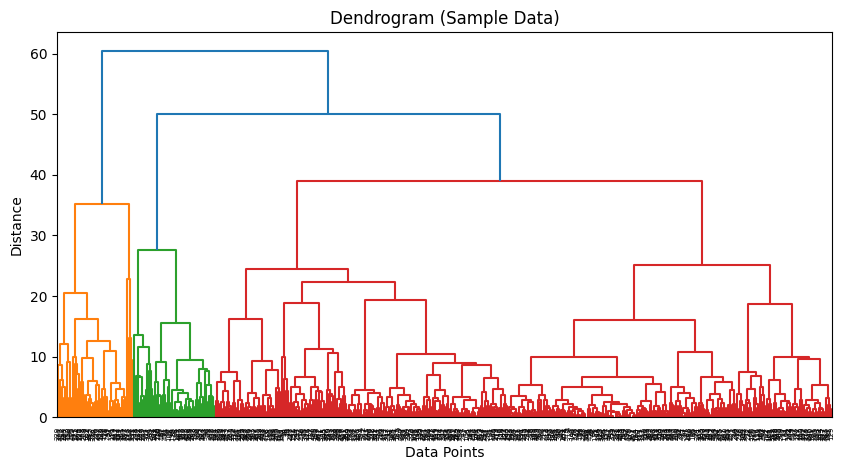

In [17]:
plt.figure(figsize=(10,5))
dendrogram(Z)
plt.title("Dendrogram (Sample Data)")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

**Step 6: Apply Clustering on FULL DATA**

In [18]:
Z_full = linkage(X_scaled, method='ward')

clusters = fcluster(Z_full, t=4, criterion='maxclust')

df['Cluster'] = clusters

**Step 7: PCA Visualization**

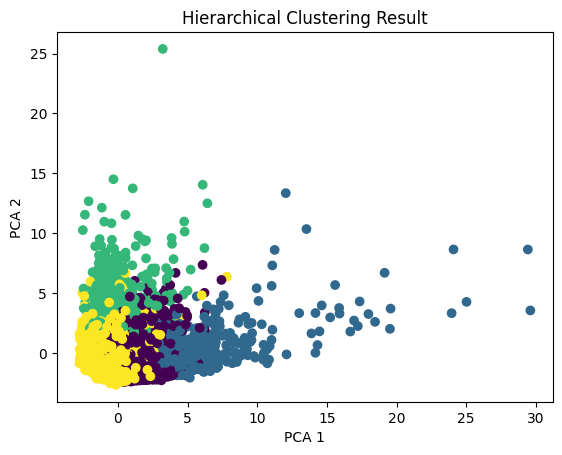

In [19]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters)
plt.title("Hierarchical Clustering Result")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()